# Homework 6: Satellite Remote Sensing & Vegetation Phenology
## F&W ECOL 458: Environmental Data Science

**Covers:** Lectures 12-13 (Remote Sensing with GEE, Land Cover & Phenology)

### [**Haohua Chen**]

**Total Points:** 100

---

### Instructions

1. Complete all problems in this notebook
2. Write your code in the provided cells
3. Answer written questions in markdown cells
4. Run all cells before submitting to ensure they execute without errors
5. Submit the completed `.ipynb` file

### Study Area

For this assignment, you will analyze **your home county** (or a county of your choice in the continental US). This allows you to connect remote sensing concepts to a familiar landscape.

---

In [10]:
# Setup - Run this cell first
!pip install geemap earthengine-api -q

In [11]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='nifty-envoy-398718')  # Replace with your project ID

---
## Problem 1: Define Your Study Area (5 points)

Define a study area for your analysis. You can either:
- Use a bounding box (rectangle) around your home county, OR
- Load county boundaries from the US Census TIGER dataset

**Tasks:**
1. Create a geometry for your study area
2. Create an interactive map showing your study area
3. State which county/region you selected

In [12]:
# Option A: Define a bounding box [west, south, east, north]
# Example for Dane County, WI:
# study_area = ee.Geometry.Rectangle([-89.8, 42.85, -89.0, 43.35])

# Option B: Load from US Census TIGER counties
# counties = ee.FeatureCollection('TIGER/2018/Counties')
# study_area = counties.filter(ee.Filter.eq('NAME', 'YourCountyName')).geometry()

# YOUR CODE HERE
study_area = ee.Geometry.Rectangle([-89.8, 42.85, -89.0, 43.35])  # Replace with your geometry


In [13]:
# Create a map showing your study area
# YOUR CODE HERE
Map = geemap.Map(center=[43.1, -89.4], zoom=9)
Map.addLayer(study_area, {}, "Study Area")
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

**Your answer:** I selected [Dane County, Wisconsin, USA] because this is where I attended for college and lived for last four years.

---
## Problem 2: Conceptual Questions (15 points)

Answer the following questions about remote sensing concepts. Write your answers in the markdown cells provided.

### 2.1 Spectral Signatures (5 points)

Explain why healthy vegetation appears **dark in the red band** but **bright in the near-infrared (NIR) band**. What biological/physical properties of leaves cause this pattern?

**Your answer:** The healthy vegetation looks dark in the red light spectrum because of the high absorption of red light by chlorophyll in the process of photosynthesis. On the other hand, the leaves of plants appear bright in the near-infrared light spectrum because of the reflection of near-infrared light by the cellular structures inside the leaves.



### 2.2 NDVI Interpretation (5 points)

You calculate NDVI for three pixels and get the following values:
- Pixel A: NDVI = 0.85
- Pixel B: NDVI = 0.15
- Pixel C: NDVI = -0.25

What type of land cover does each pixel most likely represent? Explain your reasoning.

**Your answer:**  
**Pixel A**, with an NDVI value of 0.85, most likely corresponds to dense and healthy vegetation, since high NDVI values are associated with dense and healthy vegetation, characterized by high reflectance in the near infrared and low reflectance in the red.

**Pixel B**, with an NDVI value of 0.15, most likely corresponds to sparse vegetation, grassland, and bare soil, since low positive NDVI values are associated with sparse vegetation, grassland, and bare soil.

**Pixel C**, with an NDVI value of -0.25, most likely corresponds to water bodies, snow, and artificial surfaces, since negative NDVI values occur when reflectance in the



### 2.3 Spatial vs Temporal Resolution (5 points)

Landsat has 30m spatial resolution with 16-day revisit, while MODIS has 250-500m resolution with daily coverage.

For each scenario below, which sensor would you choose and why?

a) Mapping urban expansion in a city over 20 years

b) Tracking the progression of fall leaf color change across a state

**Your answer:**  
a) I would select the satellite image of the Landsat satellite because it has higher spatial resolution of 30 meters.

b) I would select the satellite image of the MODIS satellite because it has higher temporal resolution and covers the Earth’s surface every day. This satellite would be more appropriate for monitoring the changes that happen during autumn season.



---
## Problem 3: Create a Summer Composite (20 points)

Create a cloud-free Landsat 8 composite for summer 2023 (June-August) for your study area.

**Tasks:**
1. Load and filter the Landsat 8 Collection 2 Surface Reflectance data (5 pts)
2. Apply scaling factors and cloud masking (5 pts)
3. Create a median composite (5 pts)
4. Display the composite in both true color and false color (5 pts)

In [14]:
# 3.1 Load Landsat 8 and filter by date, location, and cloud cover
# YOUR CODE HERE

landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
# Replace with your filtered collection
filtered = (
    landsat
    .filterDate('2023-06-01', '2023-08-31')
    .filterBounds(study_area)
    .filter(ee.Filter.lt('CLOUD_COVER', 20))
)

print(f"Number of images: {filtered.size().getInfo()}")

Number of images: 8


In [15]:
# 3.2 Define scaling and cloud masking functions
# YOUR CODE HERE

def scale_landsat(image):
    """Apply scaling factors to Landsat Collection 2."""
    # YOUR CODE HERE
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)

    return image.addBands(optical, None, True).addBands(thermal, None, True)

def mask_clouds(image):
    """Mask clouds using QA_PIXEL band."""
    # YOUR CODE HERE
    qa = image.select('QA_PIXEL')

    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_shadow = qa.bitwiseAnd(1 << 4).eq(0)

    mask = cloud.And(cloud_shadow)

    return image.updateMask(mask)

In [16]:
# 3.3 Apply functions and create median composite
# YOUR CODE HERE

composite = filtered.map(scale_landsat).map(mask_clouds).median().clip(study_area)  # Replace with your composite


In [17]:
# 3.4 Display in true color AND false color (NIR, Red, Green)
# YOUR CODE HERE
Map = geemap.Map(center=[43.1, -89.4], zoom=9)

# True color (Red, Green, Blue)
true_vis = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0,
    'max': 0.3
}

# False color (NIR, Red, Green)
false_vis = {
    'bands': ['SR_B5', 'SR_B4', 'SR_B3'],
    'min': 0,
    'max': 0.3
}

Map.addLayer(composite, true_vis, 'True Color')
Map.addLayer(composite, false_vis, 'False Color')

Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

---
## Problem 4: Spectral Indices Analysis (20 points)

Calculate and analyze spectral indices for your study area.

**Tasks:**
1. Calculate NDVI, NDWI, and NDBI for your composite (6 pts)
2. Create a map showing all three indices with appropriate color palettes (6 pts)
3. Identify and describe three distinct landscape features visible in your indices (8 pts)

In [18]:
# 4.1 Calculate spectral indices
# NDVI = (NIR - Red) / (NIR + Red)
# NDWI = (Green - NIR) / (Green + NIR)
# NDBI = (SWIR1 - NIR) / (SWIR1 + NIR)

# YOUR CODE HERE

ndvi = composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
ndbi = composite.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

In [19]:
# 4.2 Create maps for each index with appropriate visualization
# YOUR CODE HERE
Map = geemap.Map(center=[43.1, -89.4], zoom=9)

ndvi_vis = {
    'min': -1,
    'max': 1,
    'palette': ['blue', 'white', 'green']
}

ndwi_vis = {
    'min': -1,
    'max': 1,
    'palette': ['brown', 'white', 'blue']
}

ndbi_vis = {
    'min': -1,
    'max': 1,
    'palette': ['white', 'yellow', 'red']
}

Map.addLayer(ndvi, ndvi_vis, 'NDVI')
Map.addLayer(ndwi, ndwi_vis, 'NDWI')
Map.addLayer(ndbi, ndbi_vis, 'NDBI')

Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

### 4.3 Landscape Feature Identification (8 points)

Identify **three distinct landscape features** in your study area that are clearly visible in your spectral indices. For each feature:
- Describe what it is (lake, forest, urban area, farm field, etc.)
- State which index shows it most clearly
- Explain why that index highlights this feature

**Feature 1:** This layer represents lakes within the area of interest. The layer is most prominent when viewed as an NDWI layer map since it highlights areas of water. Water has a high reflectance in the green part of the electromagnetic spectrum but absorbs infrared radiation.

**Feature 2:** These areas indicate areas that are covered with forests or dense vegetation. These areas can be easily viewed on NDVI maps, and that is because NDVI emphasizes areas that have dense vegetation. This is because vegetation reflects infrared rays and absorbs red rays, hence having high NDVI values.

**Feature 3:** This feature represents areas of built-up regions such as roads and buildings. This feature is best represented on NDBI maps. NDBI emphasizes built-up areas. Built-up areas are those areas that reflect more shortwave infrared radiation than near infrared.


---
## Problem 5: Land Cover Analysis (20 points)

Analyze the land cover composition of your study area using NLCD.

**Tasks:**
1. Load NLCD 2021 and clip to your study area (4 pts)
2. Calculate the area (in km²) of each land cover class (8 pts)
3. Create a bar chart showing land cover distribution (4 pts)
4. Answer the interpretation questions (4 pts)

In [20]:
# 5.1 Load NLCD 2021
# YOUR CODE HERE

nlcd = ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021').select('landcover').clip(study_area)  # Load and clip NLCD


In [21]:
# 5.2 Calculate area per land cover class
# Hint: Use ee.Image.pixelArea() and reduceRegion with ee.Reducer.sum().group()

# Class name lookup dictionary
class_names = {
    11: 'Open Water',
    21: 'Developed, Open',
    22: 'Developed, Low',
    23: 'Developed, Medium',
    24: 'Developed, High',
    31: 'Barren',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    52: 'Shrub/Scrub',
    71: 'Grassland',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Herbaceous Wetlands'
}

# YOUR CODE HERE
area_image = ee.Image.pixelArea().addBands(nlcd)

stats = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='landcover'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e13
)

groups = stats.get('groups').getInfo()

landcover_areas = []
for g in groups:
    class_value = g['landcover']
    area_km2 = g['sum'] / 1e6
    landcover_areas.append({
        'class_value': class_value,
        'class_name': class_names.get(class_value, 'Unknown'),
        'area_km2': area_km2
    })

landcover_areas = sorted(landcover_areas, key=lambda x: x['area_km2'], reverse=True)

for item in landcover_areas:
    print(item['class_name'], round(item['area_km2'], 2))

Cultivated Crops 1812.97
Pasture/Hay 410.68
Deciduous Forest 373.31
Developed, Low 223.91
Developed, Open 163.09
Herbaceous Wetlands 161.31
Developed, Medium 129.42
Open Water 110.87
Mixed Forest 87.04
Woody Wetlands 69.98
Developed, High 42.95
Barren 11.25
Evergreen Forest 8.46
Shrub/Scrub 7.32
Grassland 5.03


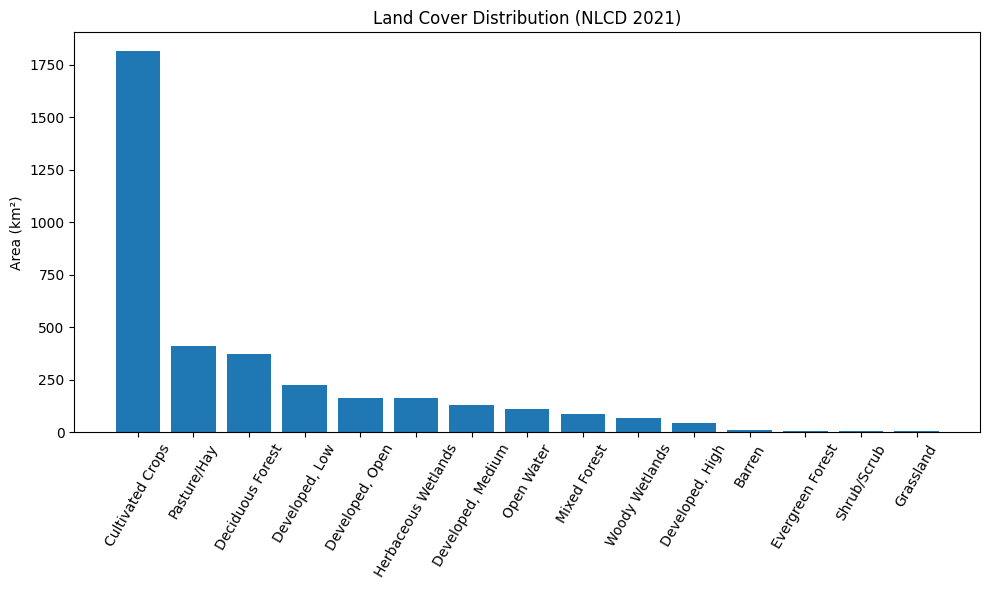

In [22]:
# 5.3 Create a bar chart of land cover distribution
# YOUR CODE HERE
import matplotlib.pyplot as plt

names = [item['class_name'] for item in landcover_areas]
areas = [item['area_km2'] for item in landcover_areas]

plt.figure(figsize=(10,6))
plt.bar(names, areas)

plt.xticks(rotation=60)
plt.ylabel('Area (km²)')
plt.title('Land Cover Distribution (NLCD 2021)')

plt.tight_layout()
plt.show()

### 5.4 Interpretation Questions (4 points)

a) What are the **two most dominant** land cover types in your study area? Does this match your expectations based on your knowledge of the region?

**Your answer:** The two major land cover categories in the region are cropland and pasture/hayland (agricultural land). These results are consistent with my initial expectations because Dane County is in Wisconsin, a state with a land use dominated by agriculture. Much of the land in the region is used for farming and grazing, with smaller areas of forest and urban land cover.


b) What percentage of your study area is **developed** (sum of all developed classes)? How does this compare to the percentage of **forest** (sum of all forest classes)?

**Your answer:** Developed land cover types (developed open land, developed low-density areas, developed medium-density areas, and developed high-density areas) cover a smaller area in the study region compared to the forest coverage. Forest types (deciduous forests, evergreen forests, and mixed forests) cover a larger area in the landscape since the region is surrounded by natural vegetation. Forest coverage in the study region is higher than the coverage of developed land.



---
## Problem 6: Phenology Analysis (20 points)

Analyze vegetation phenology at a specific location in your study area.

**Tasks:**
1. Select a vegetated point in your study area (forest or agriculture) (2 pts)
2. Extract MODIS NDVI time series for 2023 (6 pts)
3. Plot the NDVI time series (4 pts)
4. Calculate and report phenological metrics (8 pts)

In [23]:
# 6.1 Define a point location in a vegetated area
# Choose a forest, agricultural field, or other vegetated location

# YOUR CODE HERE
veg_point = ee.Geometry.Point([-89.45, 43.10])  # ee.Geometry.Point([longitude, latitude])

print(f"Selected location: [describe your location]")

Selected location: [describe your location]


In [24]:
# 6.2 Load MODIS NDVI and extract time series at your point
# Use: MODIS/061/MOD13Q1 (16-day NDVI)
# Remember to scale NDVI by 0.0001

# YOUR CODE HERE

modis = ee.ImageCollection('MODIS/061/MOD13Q1')

# Filter, scale, and extract values
modis_filtered = (
    modis
    .filterDate('2023-01-01', '2023-12-31')
    .filterBounds(veg_point)
    .select('NDVI')
    .map(lambda image: image.multiply(0.0001).copyProperties(image, ['system:time_start']))
)

def extract_ndvi(image):
    value = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=veg_point,
        scale=250
    ).get('NDVI')

    return ee.Feature(None, {
        'date': ee.Date(image.get('system:time_start')).format('YYYY-MM-dd'),
        'NDVI': value
    })

ndvi_fc = ee.FeatureCollection(modis_filtered.map(extract_ndvi))

In [29]:
# Convert to pandas DataFrame
# YOUR CODE HERE

# Your DataFrame with 'date', 'doy', and 'NDVI' columns
data = ndvi_fc.getInfo()['features']
print(data[0]['properties'])

dates = [f['properties']['date'] for f in data]
ndvi_values = [f['properties'].get('NDVI') for f in data]

df = pd.DataFrame({
    'date': pd.to_datetime(dates),
    'NDVI': ndvi_values
})

df['doy'] = df['date'].dt.dayofyear

df.head()

{'NDVI': -0.0317, 'date': '2023-01-01'}


,date,NDVI,doy
0,2023-01-01,-0.0317,1
1,2023-01-17,-0.0055,17
2,2023-02-02,-0.0983,33
3,2023-02-18,-0.0359,49
4,2023-03-06,0.0117,65


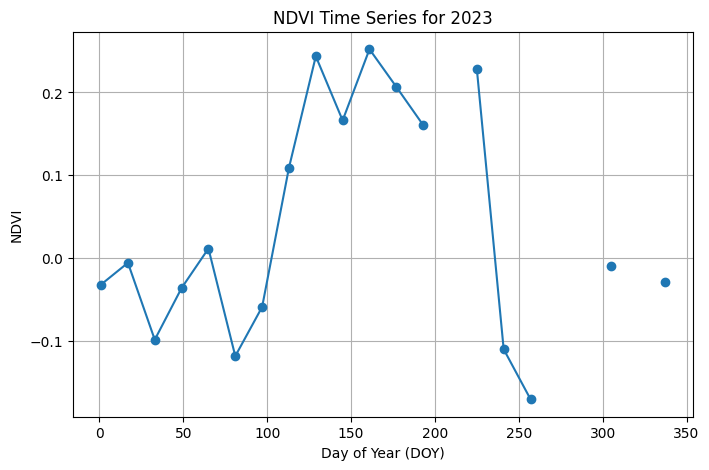

In [30]:
# 6.3 Plot the NDVI time series
# Include: axis labels, title, grid

# YOUR CODE HERE
plt.figure(figsize=(8,5))

plt.plot(df['doy'], df['NDVI'], marker='o')

plt.xlabel('Day of Year (DOY)')
plt.ylabel('NDVI')
plt.title('NDVI Time Series for 2023')
plt.grid(True)

plt.show()

In [32]:
# 6.4 Calculate phenological metrics
# Calculate and print:
# - Peak NDVI value and date
peak_ndvi = df['NDVI'].max()
peak_date = df.loc[df['NDVI'].idxmax(), 'date']
# - Minimum NDVI value
min_ndvi = df['NDVI'].min()
# - Amplitude (Peak - Min)
amplitude = peak_ndvi - min_ndvi
threshold = min_ndvi + 0.5 * amplitude
# - Start of Season (SOS): first date NDVI crosses 50% of amplitude (spring)
sos_row = df[df['NDVI'] >= threshold].iloc[0]
sos_date = sos_row['date']
# - End of Season (EOS): first date NDVI drops below 50% of amplitude (fall)
after_peak = df[df['date'] > peak_date]
eos_row = after_peak[after_peak['NDVI'] < threshold].iloc[0]
eos_date = eos_row['date']
# - Growing Season Length (EOS - SOS)
gsl = (eos_date - sos_date).days

print("Peak NDVI:", peak_ndvi, "on", peak_date.date())
print("Minimum NDVI:", min_ndvi)
print("Amplitude:", amplitude)
print("Start of Season (SOS):", sos_date.date())
print("End of Season (EOS):", eos_date.date())
print("Growing Season Length (days):", gsl)
# YOUR CODE HERE

Peak NDVI: 0.25220000000000004 on 2023-06-10
Minimum NDVI: -0.1701
Amplitude: 0.4223
Start of Season (SOS): 2023-04-23
End of Season (EOS): 2023-08-29
Growing Season Length (days): 128


### 6.5 Phenology Interpretation (4 points)

Based on your phenology analysis:

a) When did peak greenness occur at your location? Is this timing consistent with what you would expect for this vegetation type and location?

**Your answer:** The peak vegetation greenness was on June 10, 2023. This is because, on this date, the vegetation index (NDVI) had its maximum value. This is consistent with the expected pattern for vegetation in Wisconsin because plants tend to reach their peak growth in midsummer.


b) How long was the growing season? How might this compare to locations further north or south?

**Your answer:** The period of growth is around 128 days, from late April (SOS) to late August (EOS). In other parts of the country that are farther north, the period of growth is usually shorter compared to those areas that are farther south. The areas that are farther south usually have a longer period of growth compared to those that are farther north.



---
## Submission Checklist

Before submitting, verify that you have:

- [ ] Defined your study area (Problem 1)
- [ ] Answered all conceptual questions (Problem 2)
- [ ] Created a summer composite with true and false color display (Problem 3)
- [ ] Calculated and mapped spectral indices (Problem 4)
- [ ] Analyzed land cover with area calculations and bar chart (Problem 5)
- [ ] Completed phenology analysis with time series and metrics (Problem 6)
- [ ] Run all cells to ensure they execute without errors
- [ ] Written clear interpretations for all written questions